# Null Model Comparison: ER vs. Configuration Model
Compares the real O\*NET graph against two null models on clustering coefficient and average path length.

### Tools:
Claude was used for error correction and code restructuring.

### Required Files:
`Edges.csv`

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 130
})

## 1. Build Graph & Real Metrics

In [3]:
# Load the edges file and build the full occupation similarity graph
edges = pd.read_csv("Edges.csv")
# nx.from_pandas_edgelist: https://networkx.org/documentation/stable/reference/generated/networkx.convert_matrix.from_pandas_edgelist.html
G = nx.from_pandas_edgelist(edges, source='Source', target='Target', edge_attr='Weight')
# nx.connected_components: NetworkX library — https://networkx.org/documentation/stable/reference/algorithms/component.html
LCC = G.subgraph(max(nx.connected_components(G), key=len)).copy()

# Extract the Largest Connected Component so path length can be computed
# Disconnected graphs have no defined average shortest path length
n = LCC.number_of_nodes()
p = nx.density(LCC)

# Compute real network clustering and path length as the baseline
# nx.average_clustering: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.average_clustering.html
C_real = nx.average_clustering(LCC)
# nx.average_shortest_path_length: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.generic.average_shortest_path_length.html
L_real = nx.average_shortest_path_length(LCC)

print(f"LCC: {n} nodes, density={p:.4f}")
print(f"Real graph  ->  C = {C_real:.4f},  L = {L_real:.4f}")

LCC: 454 nodes, density=0.0293
Real graph  ->  C = 0.4051,  L = 4.0576


## 2. Null Model 1 Erdos-Renyi
Rewires all edges randomly. Preserves only the number of nodes and mean degree.

In [4]:
# Number of null model networks to generate per model type
N_SIM = 1000

print(f"Simulating {N_SIM} ER graphs (n={n}, p={p:.4f})")
er_C, er_L = [], []
for i in range(N_SIM):
    # nx.erdos_renyi_graph: https://networkx.org/documentation/stable/reference/generated/networkx.generators.random_graphs.erdos_renyi_graph.html
    er = nx.erdos_renyi_graph(n, p, seed=i)
    # nx.is_connected: NetworkX library
    if nx.is_connected(er):
        er_C.append(nx.average_clustering(er))
        er_L.append(nx.average_shortest_path_length(er))

print(f"  Connected graphs : {len(er_C)}/{N_SIM}")
print(f"  ER  C = {np.mean(er_C):.4f} +/- {np.std(er_C):.4f}")
print(f"  ER  L = {np.mean(er_L):.4f} +/- {np.std(er_L):.4f}")

Simulating 1000 ER graphs (n=454, p=0.0293)
  Connected graphs : 999/1000
  ER  C = 0.0294 +/- 0.0017
  ER  L = 2.6452 +/- 0.0130


## 3. Null Model 2 Configuration Model / Degree-Preserving (DP)
Rewires edges randomly while preserving the exact degree of every node.

In [5]:
# Extract the degree sequence of the LCC to use in the configuration model
degree_seq = [d for _, d in LCC.degree()]

print(f"Simulating {N_SIM} Configuration Model graphs")
dp_C, dp_L = [], []
for i in range(N_SIM):
    # nx.configuration_model: https://networkx.org/documentation/stable/reference/generated/networkx.generators.degree_seq.configuration_model.html
    cm = nx.configuration_model(degree_seq, seed=i)
    # convert to simple graph to remove multi-edges
    cm = nx.Graph(cm)  
    # remove multi-edges
    cm.remove_edges_from(nx.selfloop_edges(cm))
    if nx.is_connected(cm):
        # Only compute stats if the graph is connected
        dp_C.append(nx.average_clustering(cm))
        dp_L.append(nx.average_shortest_path_length(cm))

print(f"  Connected graphs : {len(dp_C)}/{N_SIM}")
print(f"  DP  C = {np.mean(dp_C):.4f} +/- {np.std(dp_C):.4f}")
print(f"  DP  L = {np.mean(dp_L):.4f} +/- {np.std(dp_L):.4f}")

Simulating 1000 Configuration Model graphs
  Connected graphs : 786/1000
  DP  C = 0.0685 +/- 0.0046
  DP  L = 2.7831 +/- 0.0110


## 4. Summary Table

In [6]:
# Build a summary table comparing real network stats against both null models
summary = pd.DataFrame({
    'Metric': ['Avg Clustering Coefficient', 'Avg Path Length (LCC)'],
    'Data': [f"{C_real:.4f}", f"{L_real:.4f}"],
    'ER': [
        f"{np.mean(er_C):.4f} +/- {np.std(er_C):.4f}",
        f"{np.mean(er_L):.4f} +/- {np.std(er_L):.4f}"
    ],
    'DP (Config Model)': [
        f"{np.mean(dp_C):.4f} +/- {np.std(dp_C):.4f}",
        f"{np.mean(dp_L):.4f} +/- {np.std(dp_L):.4f}"
    ]
})
summary.set_index('Metric', inplace=True)
print(summary.to_string())

                              Data                 ER  DP (Config Model)
Metric                                                                  
Avg Clustering Coefficient  0.4051  0.0294 +/- 0.0017  0.0685 +/- 0.0046
Avg Path Length (LCC)       4.0576  2.6452 +/- 0.0130  2.7831 +/- 0.0110


## 5. Bar Graph: Real vs. ER vs. DP

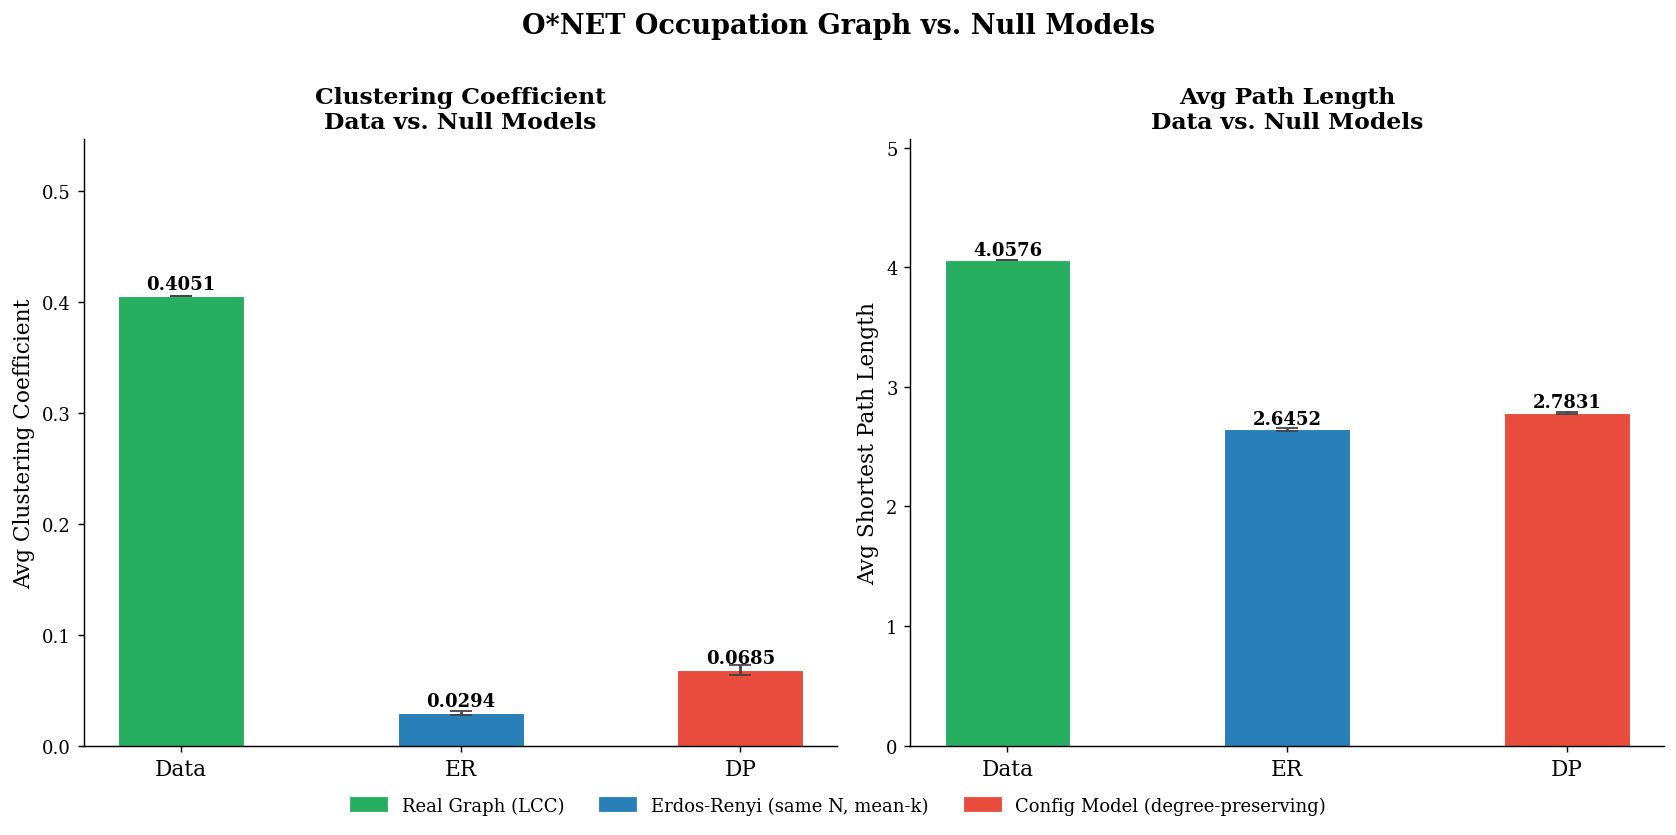

In [7]:
# Create a side-by-side bar chart comparing clustering and path length across the real network and both null models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor('#FFFFFF')   
ax1.set_facecolor('#FFFFFF')          
ax2.set_facecolor('#FFFFFF')          

COLORS = {
    'Data': '#27AE60',
    'ER':   '#2980B9',
    'DP':   '#E74C3C',
}
labels = ['Data', 'ER', 'DP']
x      = np.arange(len(labels))
bar_w  = 0.45

# Panel A: Clustering Coefficient
c_vals = [C_real,        np.mean(er_C),   np.mean(dp_C)]
c_errs = [0,             np.std(er_C),    np.std(dp_C)]

bars1 = ax1.bar(x, c_vals, width=bar_w,
                color=[COLORS[l] for l in labels],
                edgecolor='white', linewidth=0.6,
                yerr=c_errs, capsize=6,
                error_kw=dict(ecolor='#444', elinewidth=1.5))

# Add value labels above each bar
for bar, val in zip(bars1, c_vals):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(c_errs)*0.15 + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=12)
ax1.set_ylabel('Avg Clustering Coefficient', fontsize=12)
ax1.set_title('Clustering Coefficient\nData vs. Null Models', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(c_vals) * 1.35)

# Panel B: Average Path Length
l_vals = [L_real,        np.mean(er_L),   np.mean(dp_L)]
l_errs = [0,             np.std(er_L),    np.std(dp_L)]

bars2 = ax2.bar(x, l_vals, width=bar_w,
                color=[COLORS[l] for l in labels],
                edgecolor='white', linewidth=0.6,
                yerr=l_errs, capsize=6,
                error_kw=dict(ecolor='#444', elinewidth=1.5))

# Add value labels above each bar
for bar, val in zip(bars2, l_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(l_errs)*0.15 + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=12)
ax2.set_ylabel('Avg Shortest Path Length', fontsize=12)
ax2.set_title('Avg Path Length\nData vs. Null Models', fontsize=13, fontweight='bold')
ax2.set_ylim(0, max(l_vals) * 1.25)

# Shared legend placed at the bottom of the figure
legend_patches = [
    mpatches.Patch(color=COLORS['Data'], label='Real Graph (LCC)'),
    mpatches.Patch(color=COLORS['ER'],   label='Erdos-Renyi (same N, mean-k)'),
    mpatches.Patch(color=COLORS['DP'],   label='Config Model (degree-preserving)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.04))

fig.suptitle('O*NET Occupation Graph vs. Null Models',
             fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()